In [1]:
import numpy as np
import dynesty
import scipy
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from dynesty import plotting as dyplot
from scipy import integrate
from scipy.stats import norm
from scipy.stats import cauchy
from astroML.plotting import hist

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


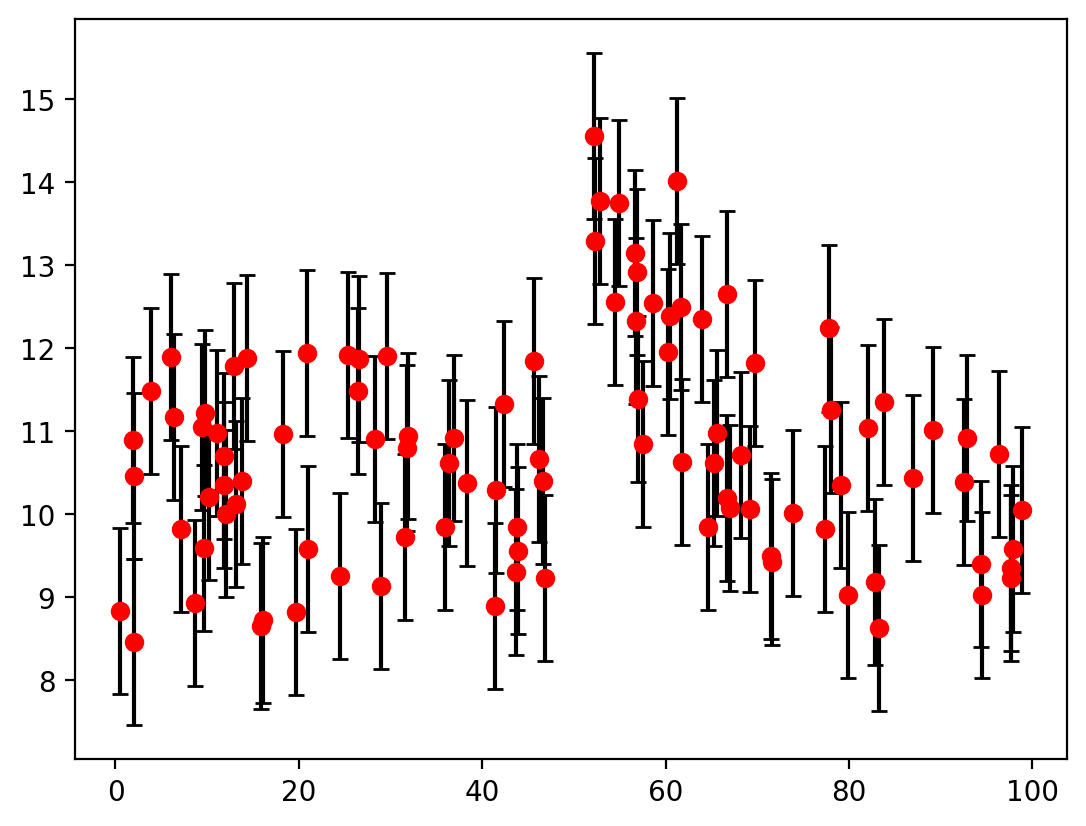

In [2]:
#importo i dati
data = np.load('transient.npy')

#identifico i singoli dati 
time = data[: , 0]
flux = data [: , 1]
sigma = data[: , 2]

#plotto i dati iniziali
plt.errorbar(data[: , 0], data[: , 1], data[: , 2] ,fmt='ro', ecolor='black', capsize=3)
plt.show()

In [3]:
#definisco il burst model 
def f_scalar(b , t_0 , A , alpha, t):
    if (t < t_0):
        return b
    else:
        return b + A*np.exp(-alpha * (t - t_0))
    
#uso vectorize per permettere alla funzione di agire sui singoli elementi di un array
f = np.vectorize(f_scalar)

In [4]:
#defince dimensionality of parameter space
ndim = 4

In [5]:
def log_like(gamma):
    b_new, A_new,t_0_new, alpha_new = gamma
    sigma2 = sigma ** 2
    return -0.5 * np.sum((flux - f(gamma[0], gamma[1], gamma[2], gamma[3], time)) ** 2 / sigma2)

def prior( u ):
    b = scipy.stats.uniform.ppf(u[0], loc=7, scale=6)
    t_0 = scipy.stats.uniform.ppf(u[1], loc=45, scale=10)
    A = scipy.stats.uniform.ppf(u[2], loc=0, scale=10)
    ln_alpha = scipy.stats.uniform.ppf(u[3], loc=0, scale=0.2)
    return [b, t_0, A, ln_alpha]

In [6]:
sampler = dynesty.NestedSampler(log_like, prior, ndim)
sampler.run_nested()
sresults = sampler.results

3747it [00:50, 74.58it/s, +500 | bound: 14 | nc: 1 | ncall: 26961 | eff(%): 16.050 | loglstar:   -inf < -48.757 <    inf | logz: -55.467 +/-  0.111 | dlogz:  0.001 >  0.509]


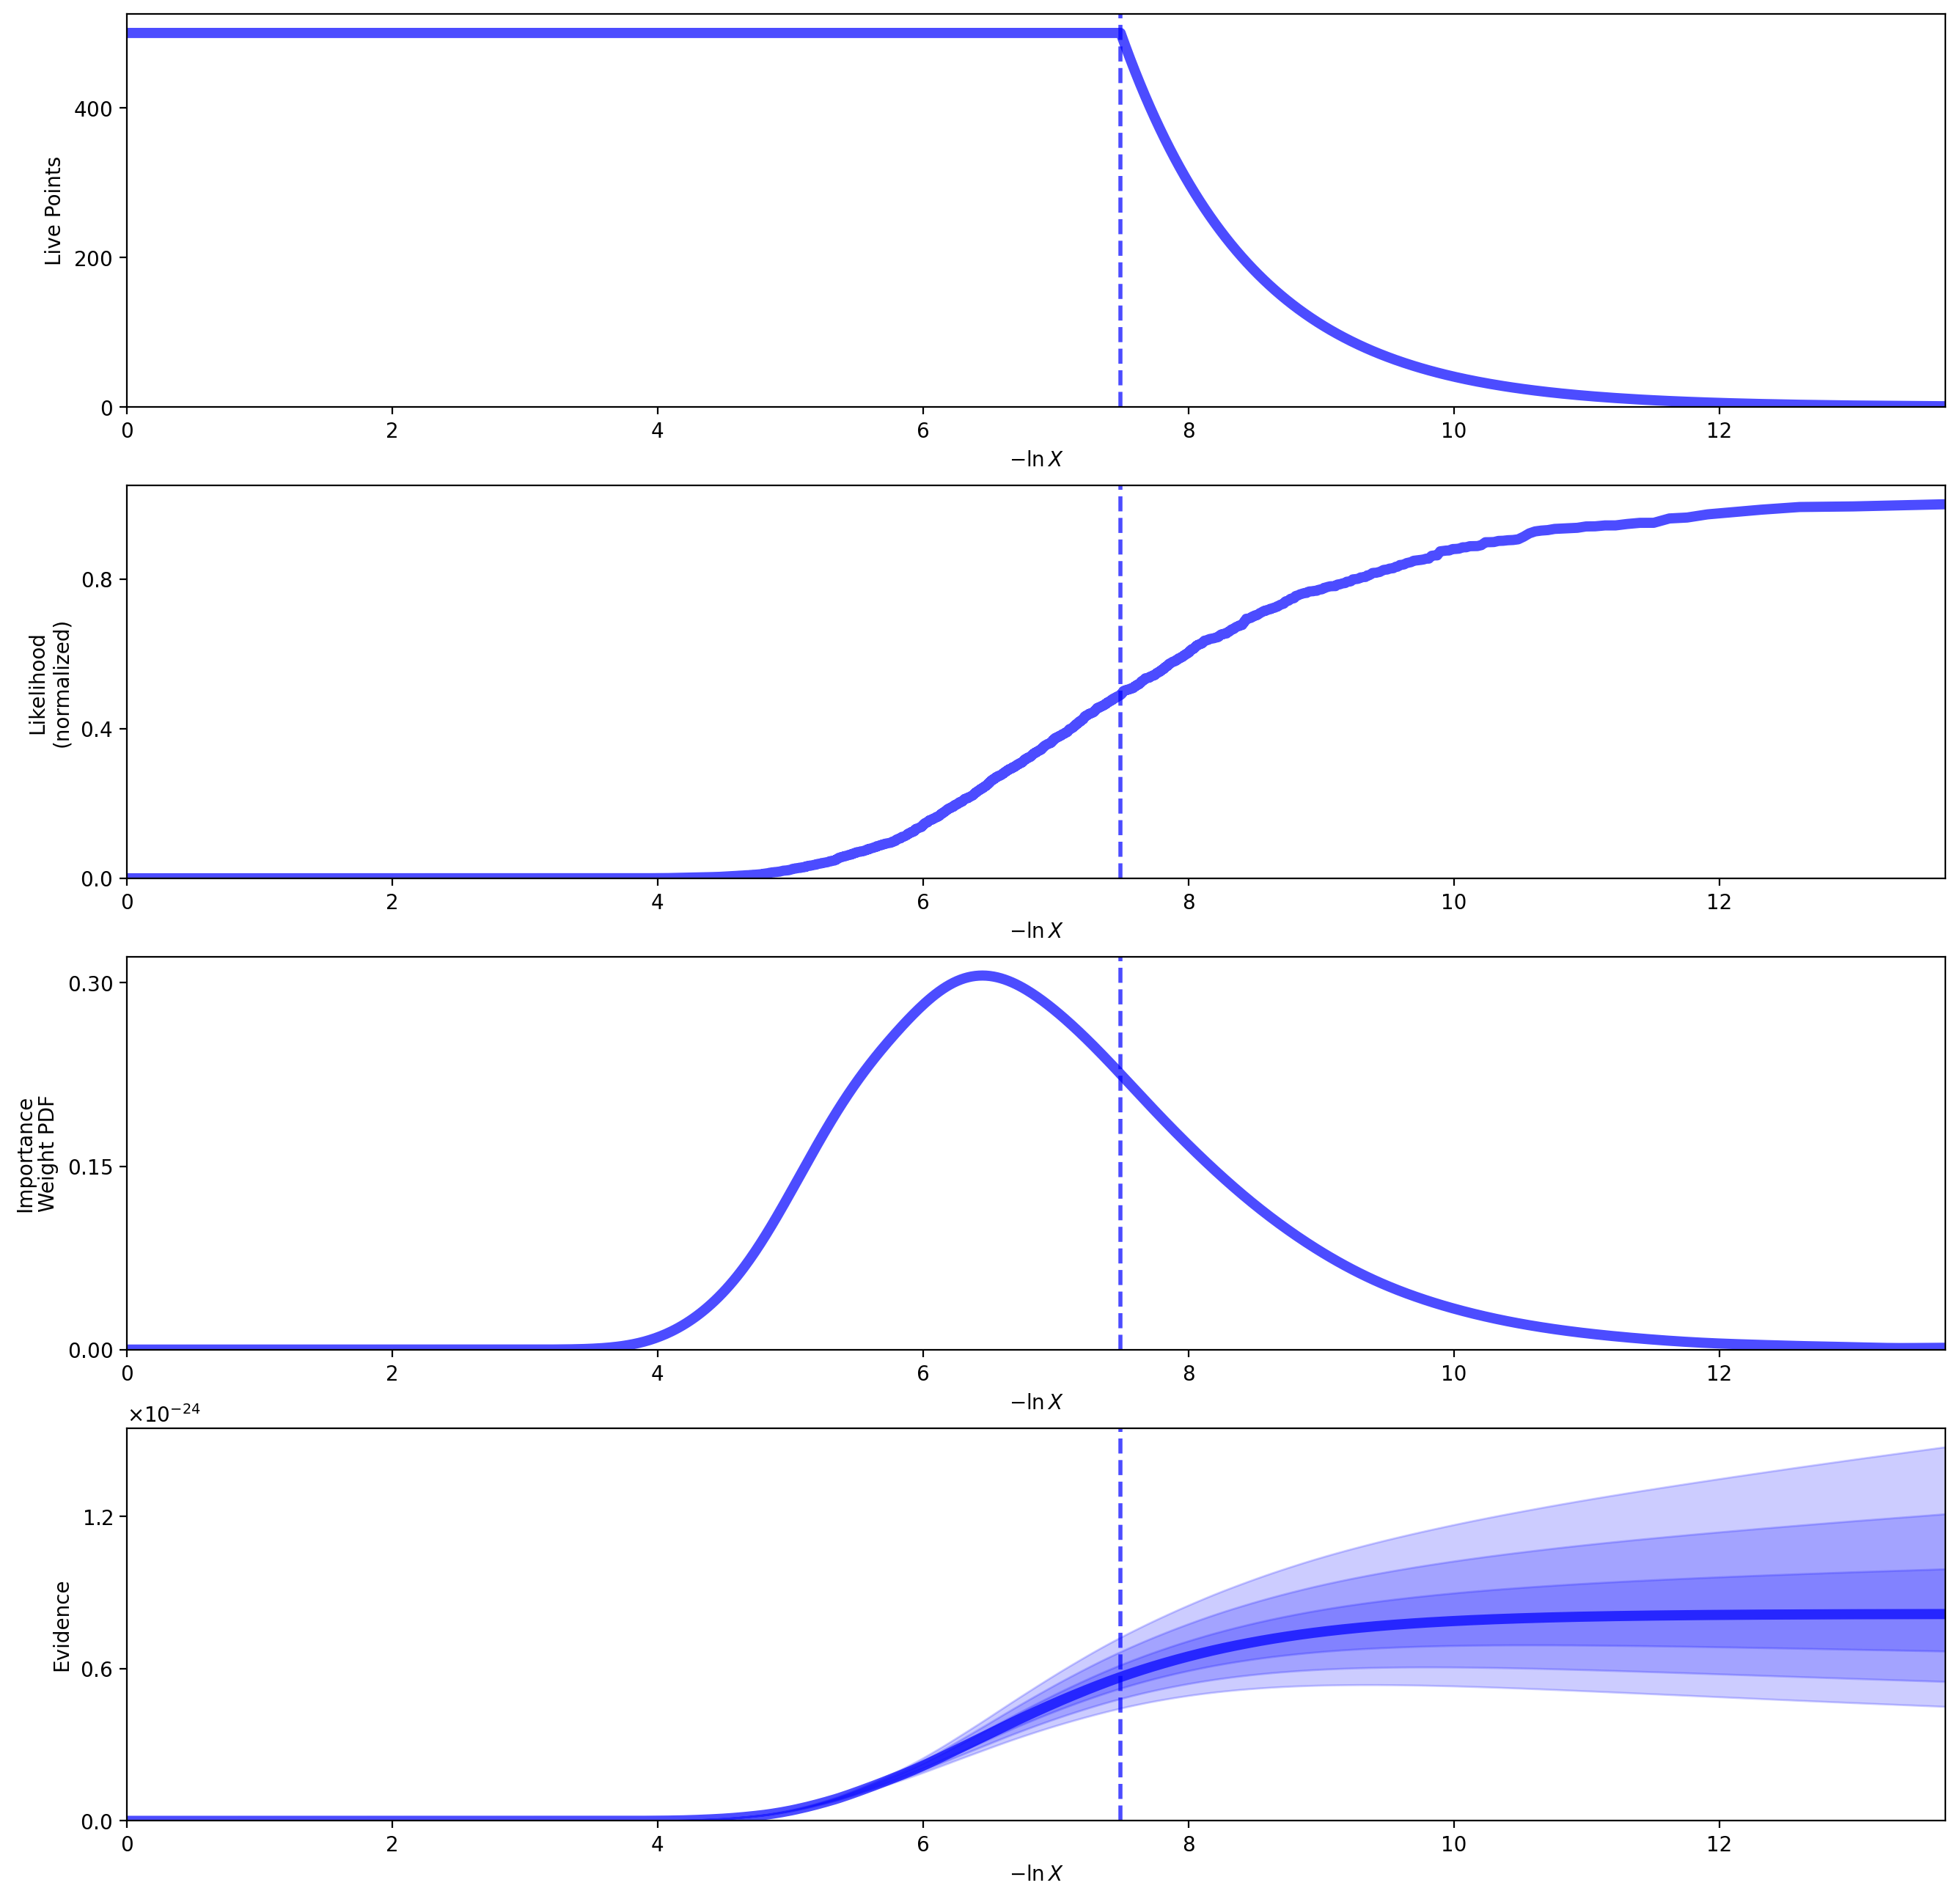

In [7]:
rfig, raxes = dyplot.runplot(sresults)

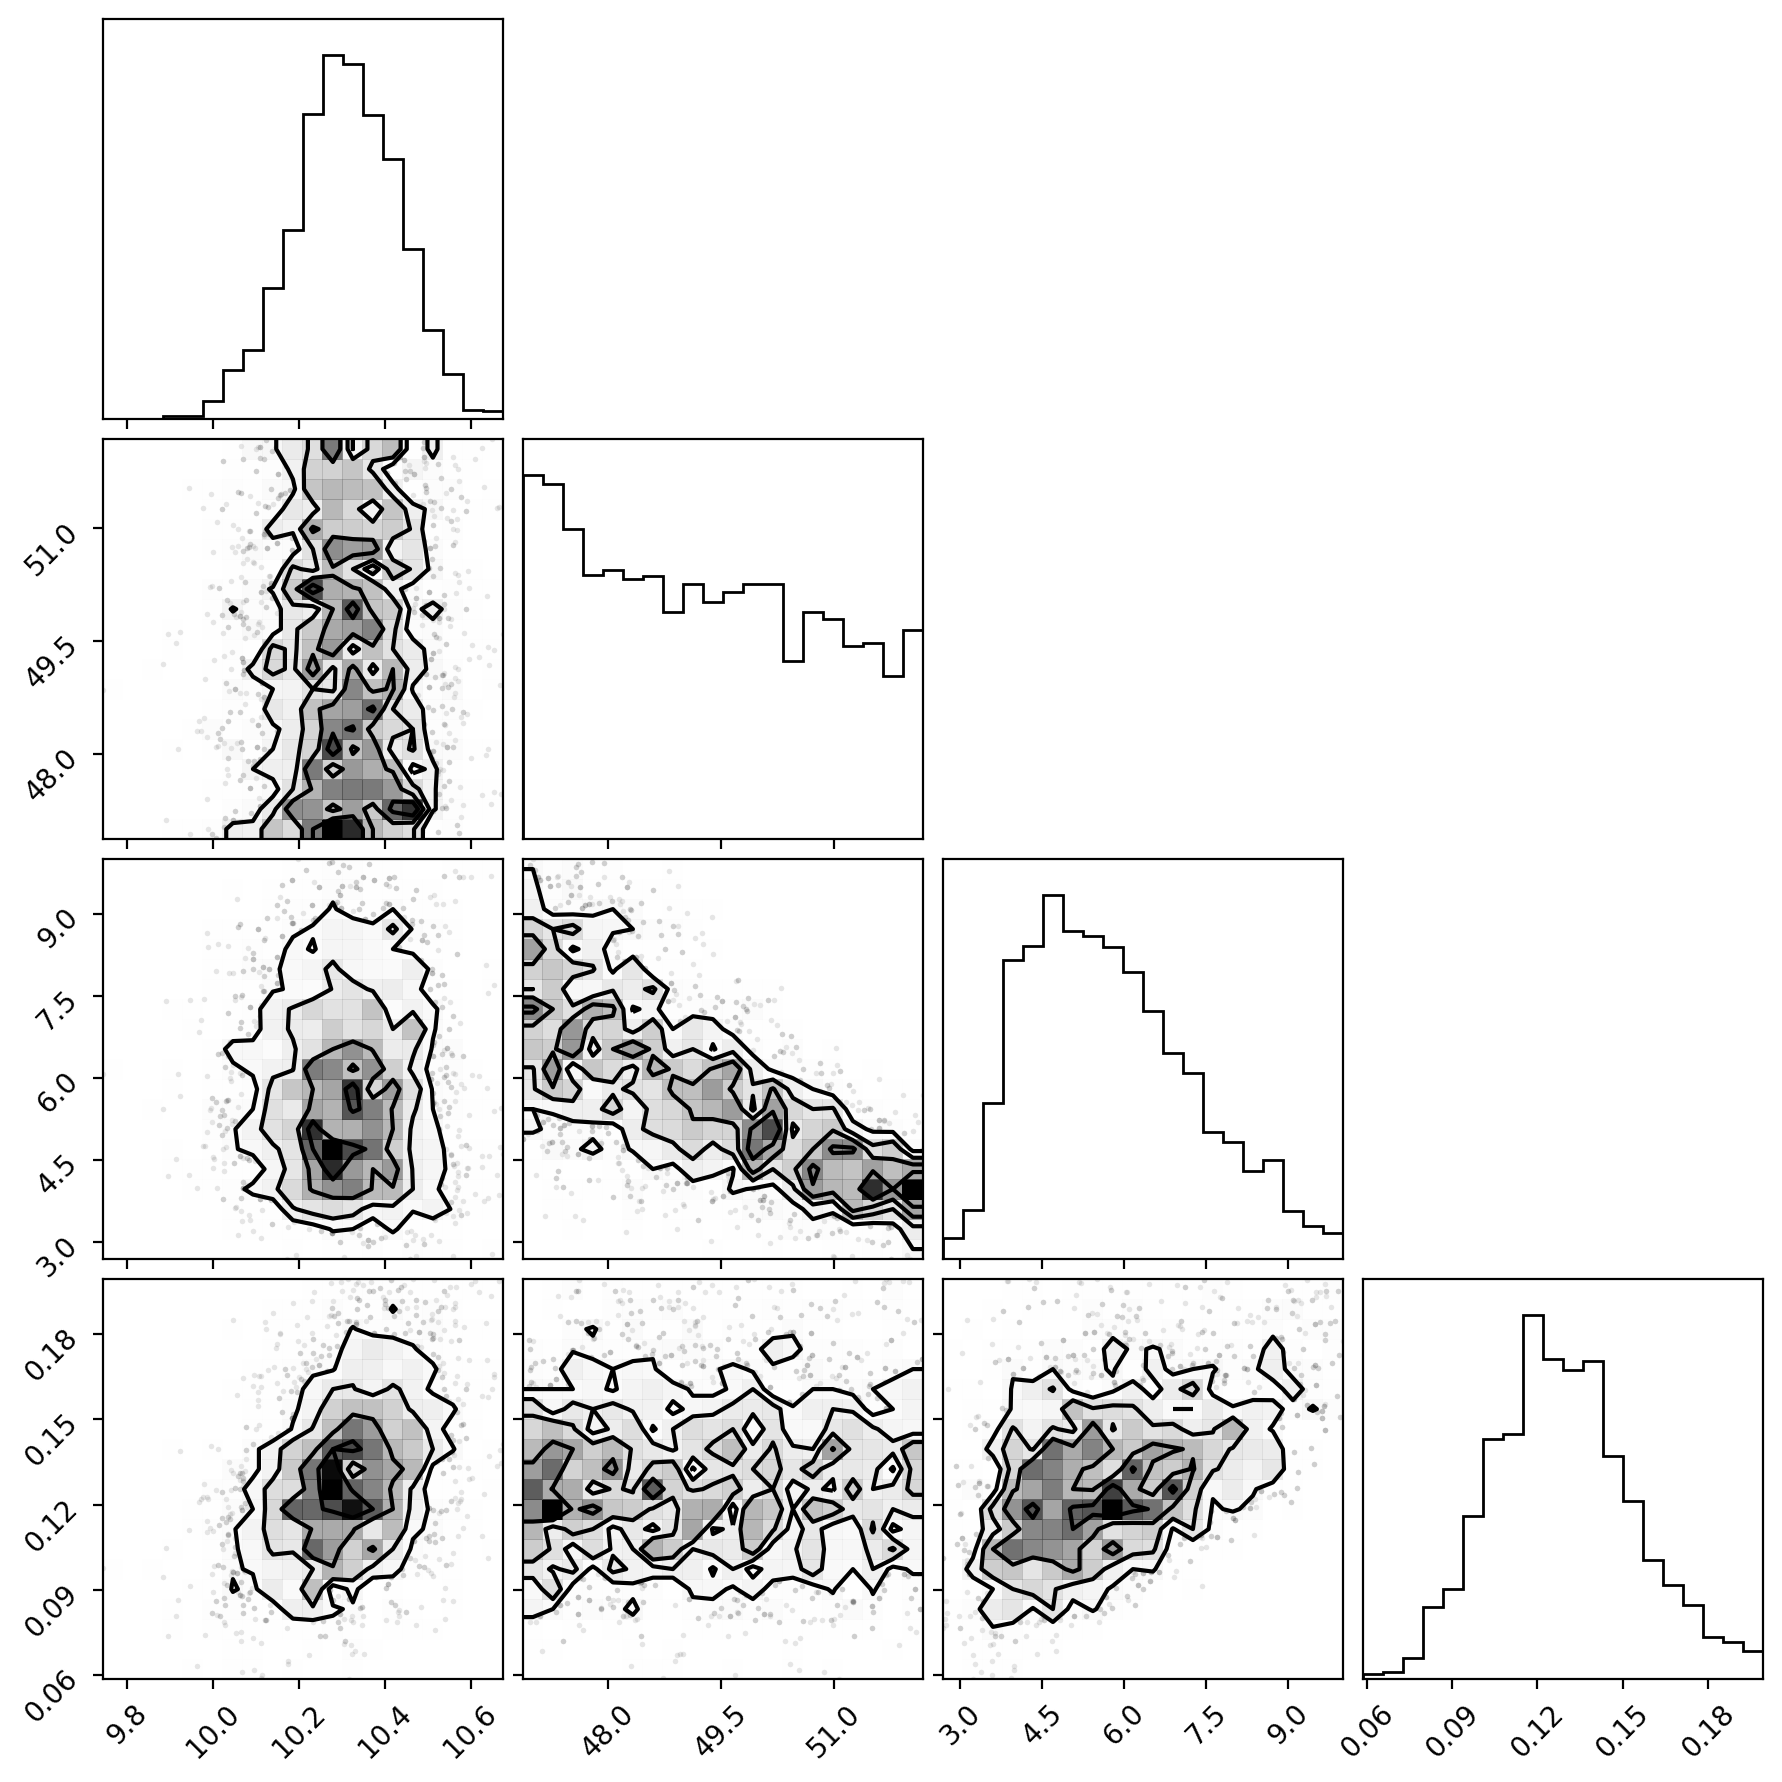

In [8]:
from dynesty import utils as dyfunc
import corner

samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1]) 

samples_equal = dyfunc.resample_equal(samples, weights)

corner.corner(samples_equal);

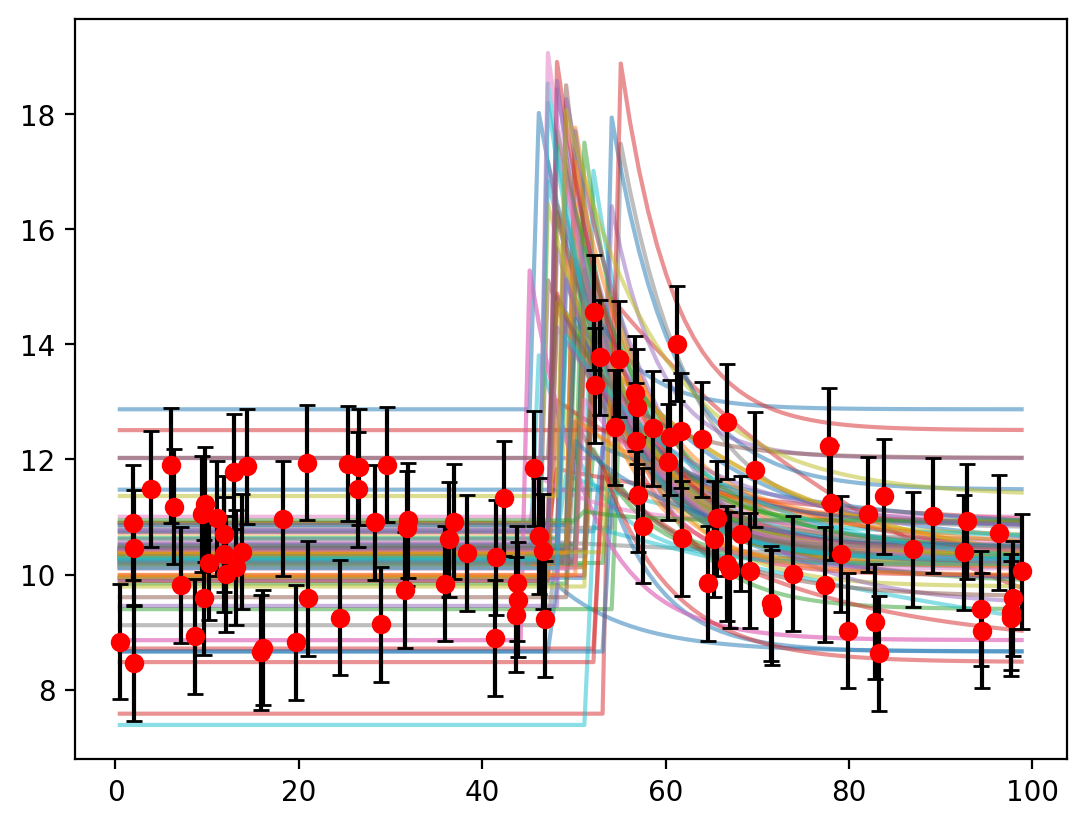

In [9]:
params = np.zeros((100,4))
index = np.random.uniform(100, np.size(samples[:,0]), 100)
x = np.linspace(min(time) , max(time),100)
for i in range (100):
    params[i ,:] = samples[int(index[i]),:]
    plt.plot(x , f(params[i][0], params[i][1] , params[i][2], params[i][3], x),alpha=0.5)
plt.errorbar(data[: , 0], data[: , 1], data[: , 2] ,fmt='ro', ecolor='black', capsize=3)
params
plt.show()

<ErrorbarContainer object of 3 artists>

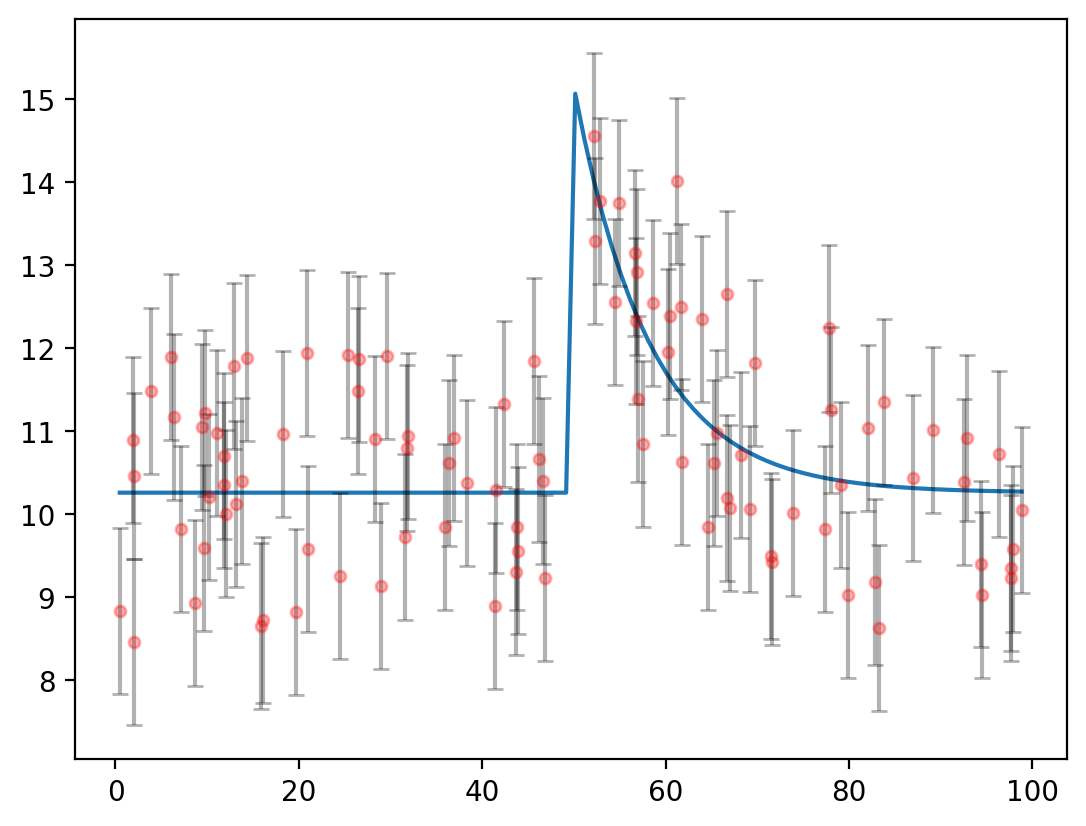

In [10]:
mean_params = np.mean(params, axis = 0) 
plt.plot(x , f(mean_params[0], mean_params[1] , mean_params[2], mean_params[3], x))
plt.errorbar(data[: , 0], data[: , 1], data[: , 2] ,fmt='ro', ecolor='black', capsize=3 , markersize = 4 , alpha = 0.3)

<ErrorbarContainer object of 3 artists>

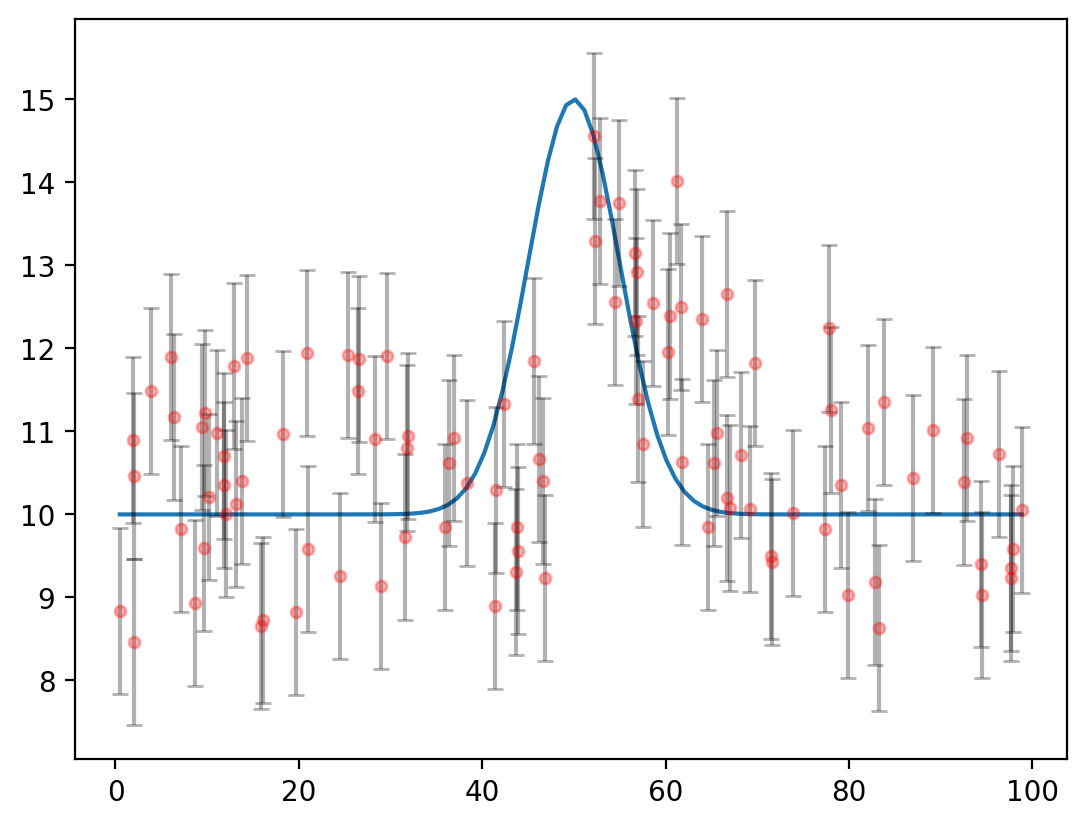

In [11]:
def g_scalar(b , t_0, A , sigmaW , t):
    return b + A*np.exp(-((t - t_0)**2 )/(2*sigmaW**2))
g = np.vectorize(g_scalar)

#provo con dei parametri che scelgo io (so gia da emcee quali sono i primi 3)
guesses = [10 , 50 , 5 , 5]

#asse x
x = np.linspace(min(time) , max(time), 100)

plt.plot(x , g(guesses[0], guesses[1], guesses[2], guesses[3],x))
plt.errorbar(data[: , 0], data[: , 1], data[: , 2] ,fmt='ro', ecolor='black', capsize=3 , markersize = 4 , alpha = 0.3)

In [14]:
#train the model with initial samples uniform centered in a small interval of the guesses

def g_prior(v):
    b = scipy.stats.uniform.ppf(v[0], loc=7, scale=6)
    t_0 = scipy.stats.uniform.ppf(v[1], loc=45, scale=10)
    A = scipy.stats.uniform.ppf(v[2], loc=0, scale=10)
    sigmaW = scipy.stats.uniform.ppf(v[3], loc=4, scale=2)
    return [b, t_0, A, sigmaW]

#define the log likelihood also for g
def g_log_like(gamma):
    b_new, A_new,t_0_new, sigmaW_new = gamma
    sigma2 = sigma ** 2
    return -0.5 * np.sum((flux - g(gamma[0], gamma[1], gamma[2], gamma[3], time)) ** 2 / sigma2)

In [15]:
sampler_g = dynesty.NestedSampler(g_log_like, g_prior, ndim)
sampler_g.run_nested()
sresults_g = sampler_g.results


4513it [00:53, 84.11it/s, +500 | bound: 12 | nc: 1 | ncall: 27111 | eff(%): 18.838 | loglstar:   -inf < -52.633 <    inf | logz: -60.929 +/-  0.126 | dlogz:  0.001 >  0.509]


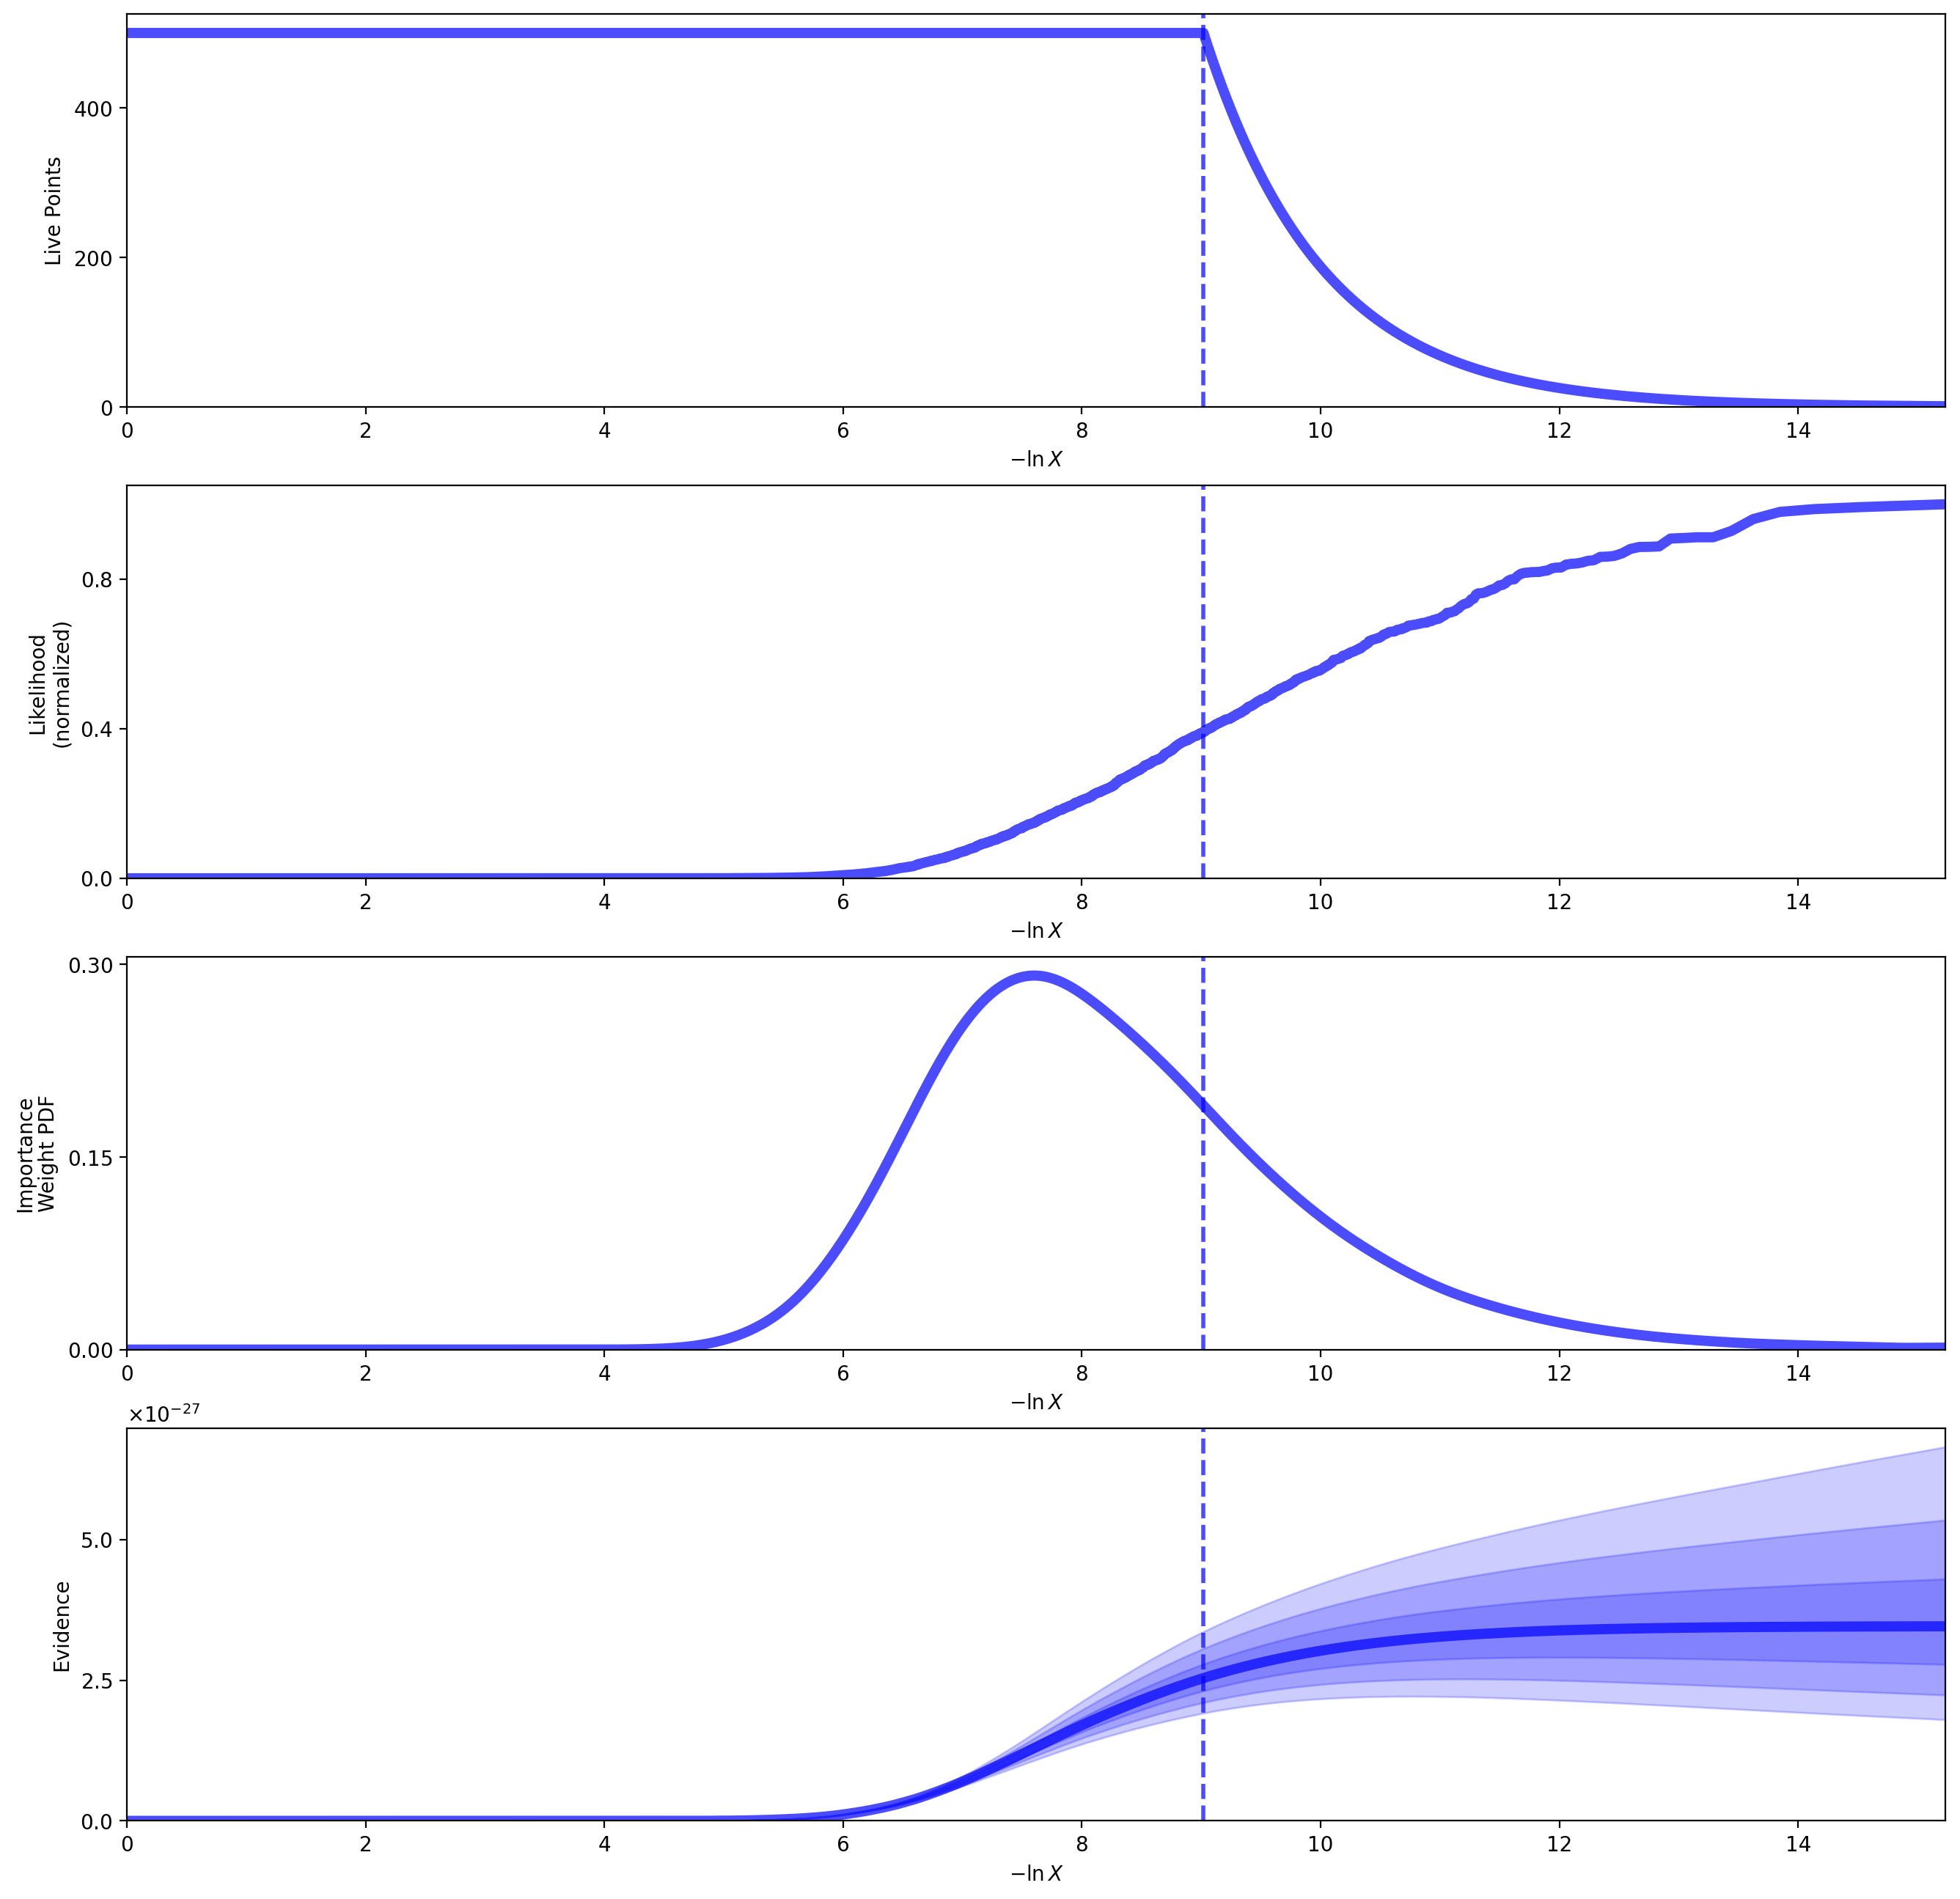

In [16]:
#plot the results
rfig_g, raxes_g = dyplot.runplot(sresults_g)

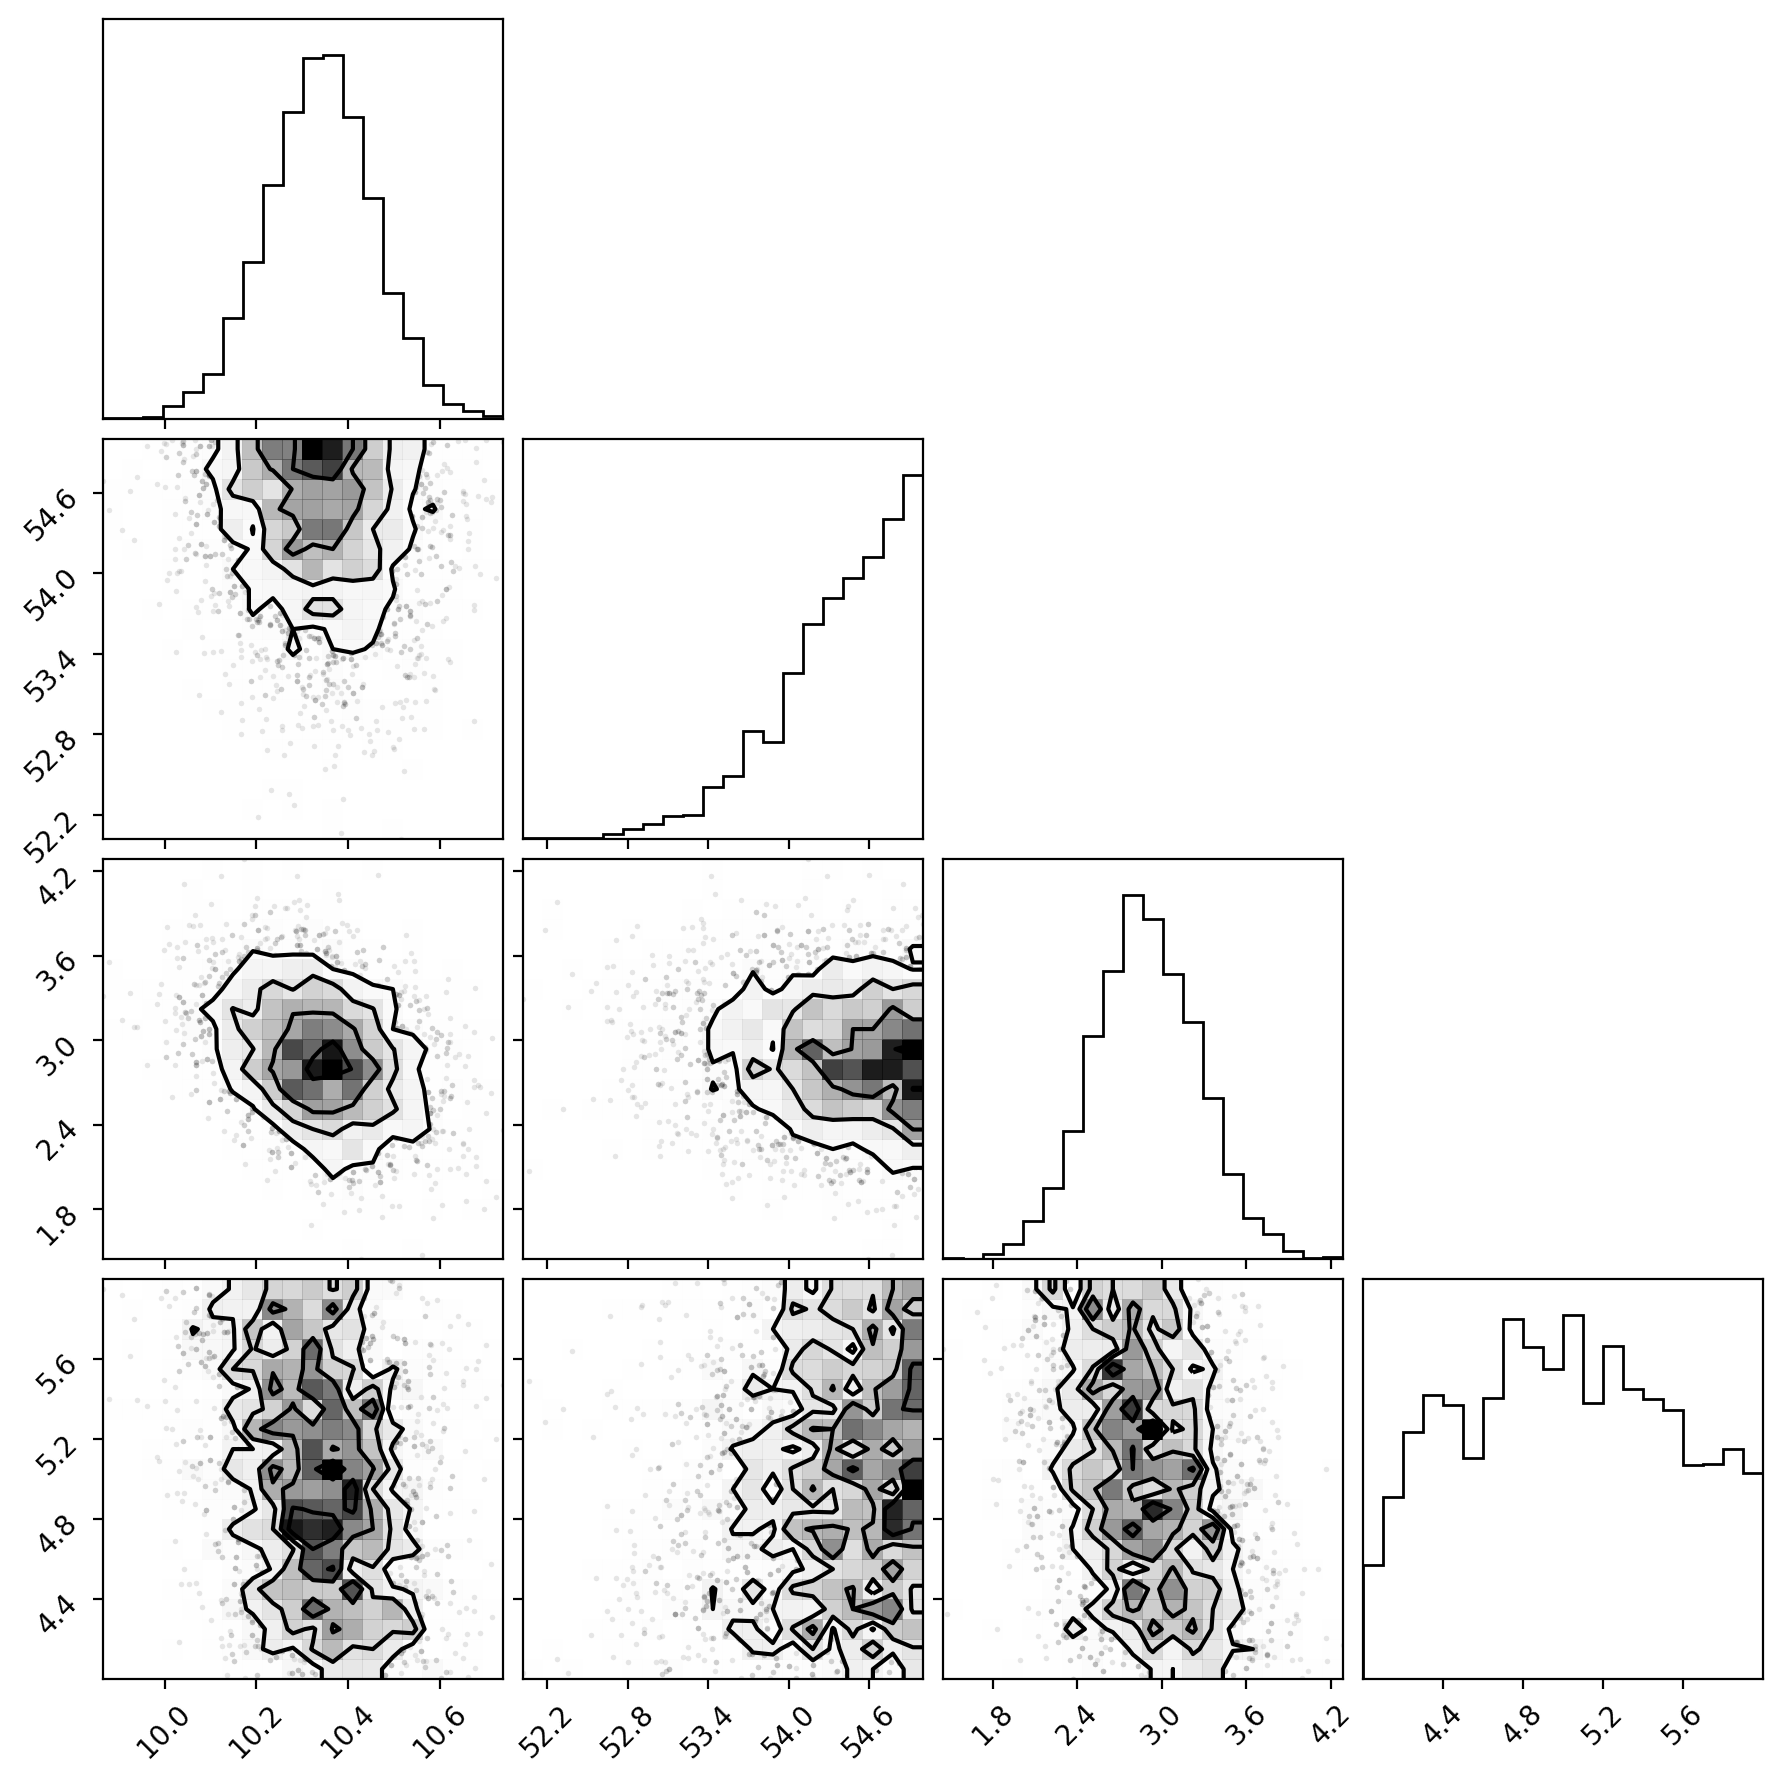

In [18]:
samples_g = sresults_g.samples  # samples
weights_g = np.exp(sresults_g.logwt - sresults_g.logz[-1]) 

samples_equal_g = dyfunc.resample_equal(samples_g, weights_g)

corner.corner(samples_equal_g);

In [19]:
evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

evidence_g = sresults_g.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence_g))

Bayesian evidence 8.147580189772503e-25
Bayesian evidence 3.458743031757876e-27
